In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Desktop/ml-project/credit_card_fraud_2025.csv")
# Basic info
print(df.head())
print(df.info())

   Transaction_ID  Customer_ID     Transaction_Date  Amount Merchant_Category  \
0               1        25795  2025-05-28 11:54:36   81.53   Online Services   
1               2        10860  2024-09-11 20:26:12   52.19              Fuel   
2               3        86820  2024-11-02 12:39:23   27.70         Utilities   
3               4        64886  2024-10-08 21:58:08    9.80          Clothing   
4               5        16265  2024-05-25 20:01:21  178.06       Electronics   

   Merchant_ID Card_Type Transaction_Type  Country  Is_International  Is_Chip  \
0         8459      Gold              POS  Germany                 1        1   
1         8205     Debit              ATM  Germany                 0        1   
2         8076      Gold           Online      USA                 0        1   
3         3244      Gold              ATM      USA                 0        1   
4         3675      Gold              ATM  Germany                 0        1   

   Is_Pin_Used  Distance_F

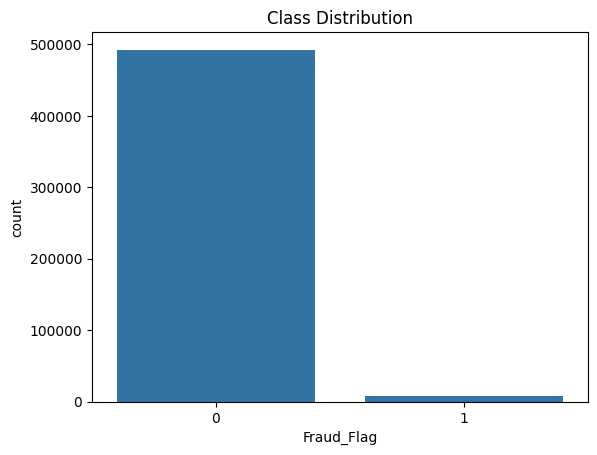

In [2]:
# Check class distribution
sns.countplot(x='Fraud_Flag', data=df)
plt.title("Class Distribution")
plt.show()

In [3]:
# Features & target
X = df.drop("Fraud_Flag", axis=1)
y = df["Fraud_Flag"]

In [4]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [7]:
print(X_train.shape)
print(y_train.shape)
print(type(X_train))
print(type(y_train))

(400000, 15)
(400000,)
<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [8]:
col = 'Transaction_Date'

X_train[col] = pd.to_datetime(X_train[col])
X_test[col] = pd.to_datetime(X_test[col])

for df in [X_train, X_test]:
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df[col + '_hour'] = df[col].dt.hour
    df[col + '_minute'] = df[col].dt.minute

X_train = X_train.drop(columns=[col])
X_test = X_test.drop(columns=[col])

In [9]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# align columns (important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


Logistic Regression
Accuracy: 0.9848
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


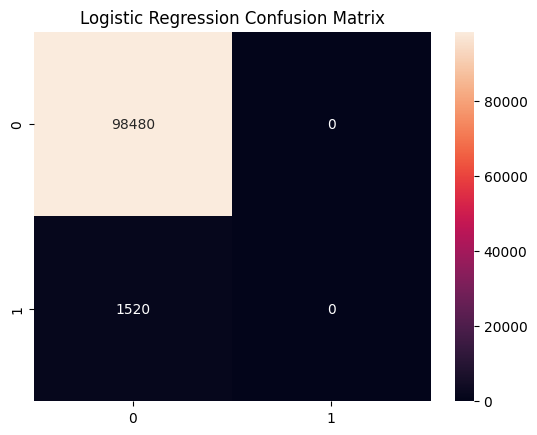


Decision Tree
Accuracy: 0.96455
Precision: 0.013922227556409025
Recall: 0.019078947368421053
F1 Score: 0.016097696364140993


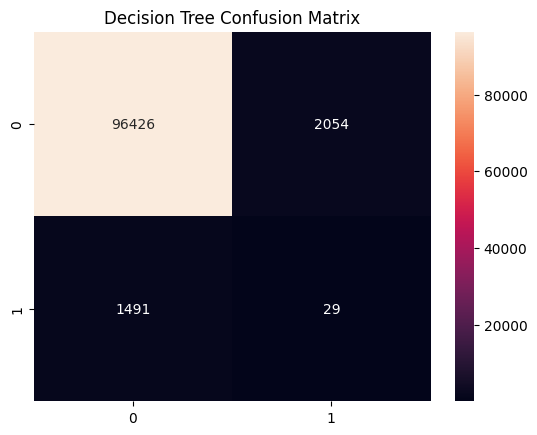


Random Forest
Accuracy: 0.9848
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


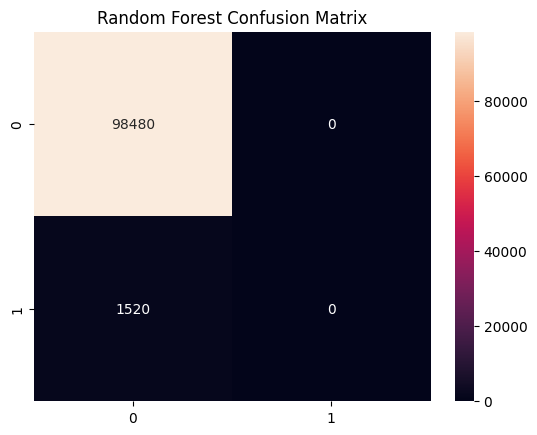

In [10]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(name + " Confusion Matrix")
    plt.show()

In [11]:
# Results table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression   0.98480   0.000000  0.000000  0.000000
1        Decision Tree   0.96455   0.013922  0.019079  0.016098
2        Random Forest   0.98480   0.000000  0.000000  0.000000
